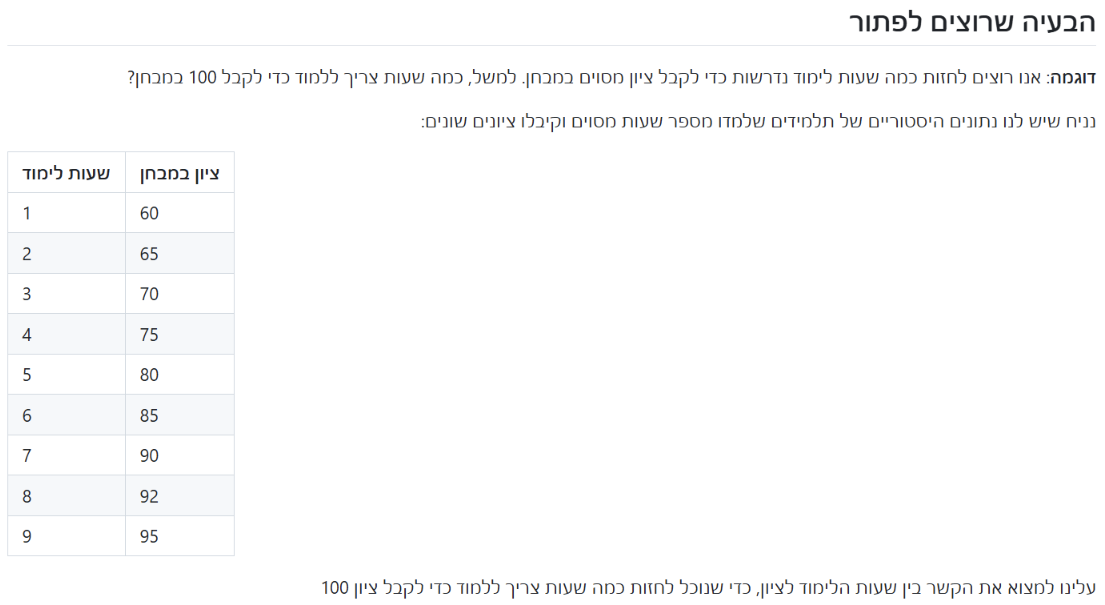

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
import time  

# ----- data -----
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9]], dtype=float)
y = np.array([60,65,70,75,80,85,90,92,95], dtype=float).reshape(-1,1)

# ----- scale X and y -----
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_s = x_scaler.fit_transform(X)
y_s = y_scaler.fit_transform(y)

# ----- ANN: linear regression as a tiny net -----
# tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
model = Sequential([Input(shape=(1,)), Dense(1, activation='linear')])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05), loss='mse')

# Start the timer
start_time = time.time()  

model.fit(X_s, y_s, epochs=1600, verbose=0)

# Stop the timer and calculate duration
end_time = time.time()  
training_time = end_time - start_time

# predictions on train (sanity check)
pred_s = model.predict(X_s, verbose=0)
pred = y_scaler.inverse_transform(pred_s)
for h, p in zip(X.ravel(), pred.ravel()):
    print(f"hours={int(h)} -> predicted score≈ {p:.1f}")

# Print training time
print(f"\nTraining completed in: {training_time:.4f} seconds")  

# ----- hours needed for score=100 -----
target_s = y_scaler.transform([[100.0]])[0,0]   # scale target
w, b = model.layers[0].get_weights()
w = float(w[0,0]); b = float(b[0])
x_needed_s = (target_s - b) / w                 # hours (scaled)
hours_needed = float(x_scaler.inverse_transform([[x_needed_s]])[0,0])
print(f"Hours needed for score 100 ≈ {hours_needed:.2f}")

hours=1 -> predicted score≈ 61.0
hours=2 -> predicted score≈ 65.6
hours=3 -> predicted score≈ 70.1
hours=4 -> predicted score≈ 74.6
hours=5 -> predicted score≈ 79.1
hours=6 -> predicted score≈ 83.6
hours=7 -> predicted score≈ 88.1
hours=8 -> predicted score≈ 92.7
hours=9 -> predicted score≈ 97.2

Training completed in: 57.7654 seconds
Hours needed for score 100 ≈ 9.62


In [2]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

GPUs available: 0
